# NB02 — Gene Structure

Before running the models we want to understand the structure of the gene expression data. Three things matter here:

1. Most genes have near-zero variance — VarianceThreshold is justified
2. The top variable genes are strongly correlated — PCA makes more sense than univariate selection
3. PCA fitted on 69 samples is noisier than PCA on 1,218 — this is the core motivation for NB04

This notebook also pins `N_COMPONENTS` so both NB03 and NB04 use the same value.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import json
import warnings
warnings.filterwarnings("ignore")


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
TABLES_DIR   = REPORTS_DIR / "tables"
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED       = 42
VAR_THRESH = 0.01
COLORS     = {"LumA": "#3498db", "LumB": "#2ecc71", "Her2": "#e74c3c", "Basal": "#9b59b6"}


## Load Data

In [3]:
def norm_id(sid):
    sid = str(sid).strip()
    return sid[:15] if sid.startswith("TCGA-") and len(sid) >= 15 else sid

expr = pd.read_csv(DATA_DIR / "HiSeqV2.csv", index_col=0)
if any(str(c).startswith("TCGA-") for c in expr.columns[:10]):
    expr = expr.T
expr.index = [norm_id(s) for s in expr.index]
expr = expr.apply(pd.to_numeric, errors="coerce")

pam = pd.read_csv(DATA_DIR / "brca_pam50.csv")
_SC_COLS = ["Sample", "sample", "sample_id", "SampleID", "TCGA_ID", "bcr_patient_barcode"]
_LC_COLS = ["PAM50", "pam50", "Subtype", "subtype", "BRCA_Subtype_PAM50"]
_sc = next((c for c in _SC_COLS if c in pam.columns), pam.columns[0])
_lc = next((c for c in _LC_COLS if c in pam.columns), None)
if _lc is None:
    _lc = next((c for c in pam.columns
                if "pam" in c.lower() or "subtype" in c.lower()), pam.columns[1])
pam = pam[[_sc, _lc]].copy()
pam.columns = ["sample_id", "subtype"]
pam["sample_id"] = pam["sample_id"].apply(norm_id)
pam = pam[pam["subtype"].notna()]
pam = pam[~pam["subtype"].str.lower().isin(["normal", "normal-like", "nan", "unknown"])]
pam = pam.drop_duplicates("sample_id").set_index("sample_id")

common        = expr.index.intersection(pam.index)
labeled_ids   = common.tolist()
unlabeled_ids = [s for s in expr.index if s not in set(labeled_ids)]
X_labeled     = expr.loc[labeled_ids].values.astype(float)
y_labels      = pam.loc[labeled_ids, "subtype"].values
X_unlabeled   = expr.loc[unlabeled_ids].values.astype(float)
GENE_NAMES    = expr.columns.tolist()
CLASSES       = sorted(set(y_labels))
y_arr         = np.array([CLASSES.index(c) for c in y_labels])
print(f"Labeled: {len(labeled_ids)}  Unlabeled: {len(unlabeled_ids)}  Genes: {len(GENE_NAMES):,}")


Labeled: 73  Unlabeled: 1145  Genes: 20,530


## Gene Variance

The vast majority of genes have near-zero variance across samples. Removing them before PCA speeds things up and avoids noise dimensions. `VAR_THRESH = 0.01` is conservative — we're not aggressively filtering.


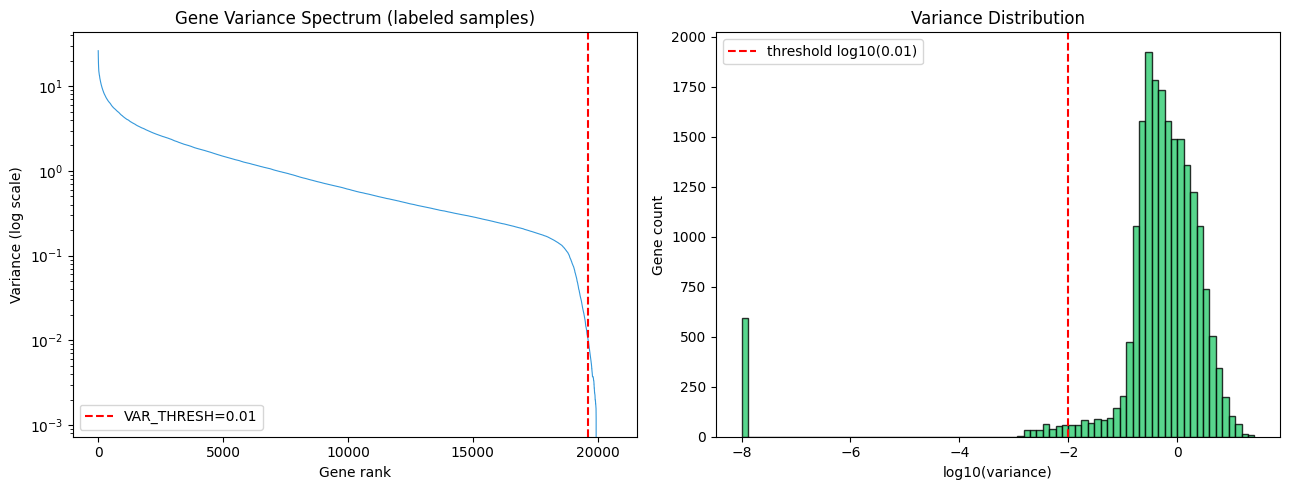

Genes passing VAR_THRESH=0.01: 19,616 / 20,530


In [4]:
gene_var = pd.Series(X_labeled.var(axis=0), index=GENE_NAMES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(range(len(gene_var)), gene_var.values, color="#3498db", lw=0.8)
ax.axvline(int((gene_var > VAR_THRESH).sum()), color="red", linestyle="--",
           label=f"VAR_THRESH={VAR_THRESH}")
ax.set_xlabel("Gene rank")
ax.set_ylabel("Variance (log scale)")
ax.set_title("Gene Variance Spectrum (labeled samples)")
ax.legend()

ax = axes[1]
ax.hist(np.log10(gene_var.values + 1e-8), bins=80, color="#2ecc71",
        edgecolor="black", alpha=0.8)
ax.axvline(np.log10(VAR_THRESH), color="red", linestyle="--",
           label=f"threshold log10({VAR_THRESH})")
ax.set_xlabel("log10(variance)")
ax.set_ylabel("Gene count")
ax.set_title("Variance Distribution")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_variance_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

n_pass = int((gene_var > VAR_THRESH).sum())
print(f"Genes passing VAR_THRESH={VAR_THRESH}: {n_pass:,} / {len(GENE_NAMES):,}")


## Gene Co-expression

The top 50 variable genes cluster into visible modules — groups that move together. This is exactly what PCA is designed to exploit. A univariate method like SelectKBest (ANOVA F-test) treats each gene independently and misses this structure entirely.


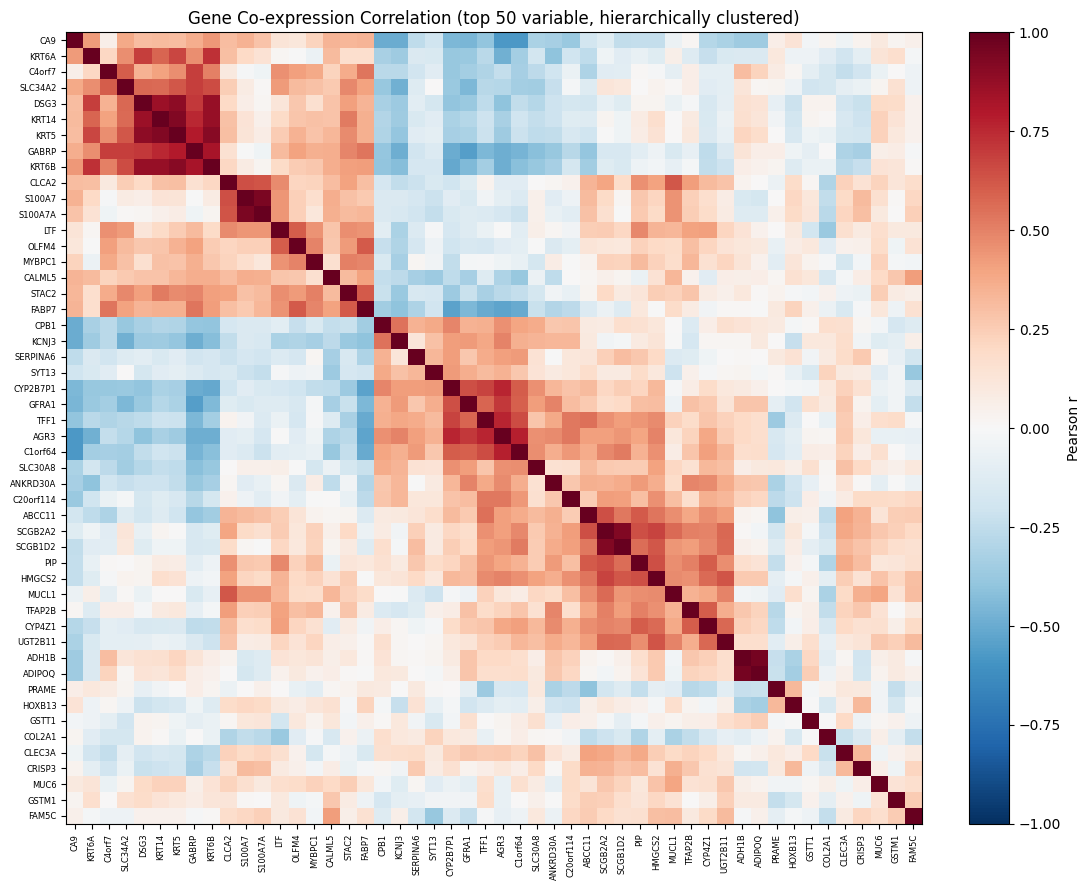

In [5]:
top50 = gene_var.nlargest(50).index.tolist()
X_top = pd.DataFrame(X_labeled, columns=GENE_NAMES)[top50]
corr  = X_top.corr()

Z     = linkage(corr.fillna(0).values, method="ward")
order = leaves_list(Z)
corr_ord = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_ord.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
ax.set_xticks(range(len(top50)))
ax.set_yticks(range(len(top50)))
ax.set_xticklabels(corr_ord.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr_ord.index, fontsize=6)
ax.set_title("Gene Co-expression Correlation (top 50 variable, hierarchically clustered)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_gene_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## PCA Stability: 69 Samples vs 1,218

With only 69 samples the eigenvalue spectrum is jagged — PCA is estimating co-expression structure from very few observations. With 1,218 samples (labeled + unlabeled) the spectrum is much smoother.

This is the empirical basis for NB04. PCA is unsupervised — it never uses labels — so adding unlabeled samples doesn't introduce any bias.


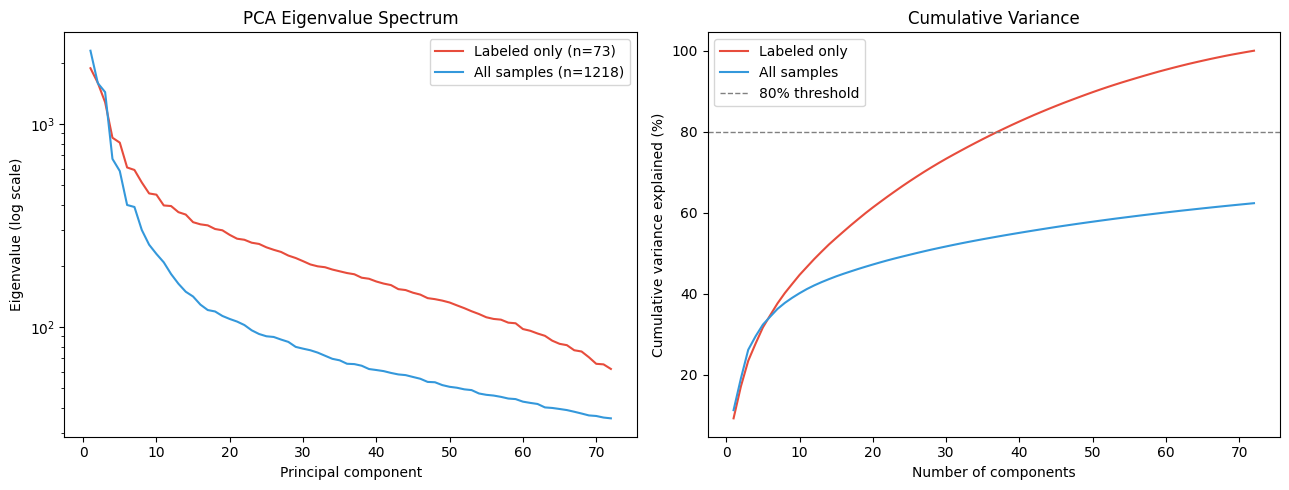

In [6]:
X_lab_scaled = StandardScaler().fit_transform(X_labeled)
X_all_raw    = np.vstack([X_labeled, X_unlabeled])
X_all_scaled = StandardScaler().fit_transform(X_all_raw)

N_EXPLORE = min(100, X_lab_scaled.shape[0] - 1, X_lab_scaled.shape[1])

pca_lab = PCA(n_components=N_EXPLORE, random_state=SEED)
pca_lab.fit(X_lab_scaled)

pca_all = PCA(n_components=N_EXPLORE, random_state=SEED)
pca_all.fit(X_all_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(range(1, N_EXPLORE+1), pca_lab.explained_variance_,
            label=f"Labeled only (n={len(labeled_ids)})", color="#e74c3c", lw=1.5)
ax.semilogy(range(1, N_EXPLORE+1), pca_all.explained_variance_,
            label=f"All samples (n={X_all_raw.shape[0]})", color="#3498db", lw=1.5)
ax.set_xlabel("Principal component")
ax.set_ylabel("Eigenvalue (log scale)")
ax.set_title("PCA Eigenvalue Spectrum")
ax.legend()

ax = axes[1]
ax.plot(range(1, N_EXPLORE+1),
        np.cumsum(pca_lab.explained_variance_ratio_) * 100,
        label="Labeled only", color="#e74c3c", lw=1.5)
ax.plot(range(1, N_EXPLORE+1),
        np.cumsum(pca_all.explained_variance_ratio_) * 100,
        label="All samples", color="#3498db", lw=1.5)
ax.axhline(80, color="gray", linestyle="--", lw=1, label="80% threshold")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative variance explained (%)")
ax.set_title("Cumulative Variance")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_pca_stability.png", dpi=150, bbox_inches="tight")
plt.show()


## How Many Components?

Two constraints:
- **Biological:** keep enough PCs to explain 80% of variance
- **Statistical:** cap at `n_labeled // 3 = 23` — rough rule to avoid overfitting   in the compressed space (at least 3 labeled samples per dimension)

`N_COMPONENTS = min(n_80_full, 23)`

Both NB03 and NB04 load this value from `02_n_components.json`.


In [7]:
cum_var_full = np.cumsum(pca_all.explained_variance_ratio_)
n_80_full    = int(np.searchsorted(cum_var_full, 0.80)) + 1

cum_var_lab  = np.cumsum(pca_lab.explained_variance_ratio_)
n_80_lab     = int(np.searchsorted(cum_var_lab, 0.80)) + 1

max_safe     = max(10, len(labeled_ids) // 3)
N_COMPONENTS = min(n_80_full, max_safe)

print("N_COMPONENTS selection:")
print(f"  n_80 on all samples:  {n_80_full}")
print(f"  n_80 on labeled only: {n_80_lab}")
print(f"  max_safe (n // 3):    {max_safe}")
print(f"  Chosen N_COMPONENTS:  {N_COMPONENTS}")


N_COMPONENTS selection:
  n_80 on all samples:  73
  n_80 on labeled only: 38
  max_safe (n // 3):    24
  Chosen N_COMPONENTS:  24


## Kruskal-Wallis Test

Quick sanity check: do the top variable genes actually differ across subtypes? We use Kruskal-Wallis (non-parametric, appropriate here) with Benjamini-Hochberg correction for the 40 tests.


In [8]:
top40 = gene_var.nlargest(40).index.tolist()

kw_results = []
for gene in top40:
    gi     = GENE_NAMES.index(gene)
    groups = [X_labeled[y_arr == i, gi] for i in range(len(CLASSES))]
    h, p   = sp_stats.kruskal(*groups)
    kw_results.append({"gene": gene, "H": h, "p_value": p})

kw_df = pd.DataFrame(kw_results).sort_values("p_value").reset_index(drop=True)
n = len(kw_df)
kw_df["rank"]  = np.arange(1, n+1)
kw_df["p_adj"] = np.minimum(1.0, kw_df["p_value"] * n / kw_df["rank"])
kw_df["p_adj"] = kw_df["p_adj"][::-1].cummin()[::-1]  # monotone BH

n_sig = (kw_df["p_adj"] < 0.05).sum()
print(f"{n_sig}/{n} top-variable genes significant after BH FDR correction")
print(kw_df[["gene", "H", "p_value", "p_adj"]].head(10).to_string(index=False))


34/40 top-variable genes significant after BH FDR correction
    gene         H      p_value        p_adj
   GABRP 45.476969 3.164132e-09 1.265653e-07
    AGR3 34.102322 7.100355e-07 1.251251e-05
   KRT6B 33.375665 1.000555e-06 1.251251e-05
CYP2B7P1 32.901498 1.251251e-06 1.251251e-05
 C1orf64 31.633539 2.273039e-06 1.818431e-05
    TFF1 31.071172 2.960741e-06 1.973827e-05
  ABCC11 28.584361 9.494109e-06 4.917000e-05
   KRT14 28.509084 9.834000e-06 4.917000e-05
   FABP7 27.708460 1.429007e-05 6.351144e-05
   KCNJ3 25.698766 3.639270e-05 1.455708e-04


## Save N_COMPONENTS

In [9]:
n_components_data = {
    "N_COMPONENTS": int(N_COMPONENTS),
    "n_80_full":    int(n_80_full),
    "n_80_labeled": int(n_80_lab),
    "max_safe":     int(max_safe),
    "n_labeled":    int(len(labeled_ids)),
    "n_unlabeled":  int(len(unlabeled_ids)),
    "VAR_THRESH":   VAR_THRESH,
}
with open(TABLES_DIR / "02_n_components.json", "w") as f:
    json.dump(n_components_data, f, indent=2)
print("Saved: 02_n_components.json")
print(json.dumps(n_components_data, indent=2))


Saved: 02_n_components.json
{
  "N_COMPONENTS": 24,
  "n_80_full": 73,
  "n_80_labeled": 38,
  "max_safe": 24,
  "n_labeled": 73,
  "n_unlabeled": 1145,
  "VAR_THRESH": 0.01
}
